# UAS CNN

## Perbandingan MobileNetV2 dan ResNet50 untuk Identifikasi Penyakit Daun Tomat

Nama : Fariz Saputra  
NIM : 23051030002

## 1. Import Library


In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## 2. Persiapan Dataset

In [4]:
TRAIN_PATH = r"D:\ML\Tugas Akhir CNN\Dataset_UAS\train"
VAL_PATH = r"D:\ML\Tugas Akhir CNN\Dataset_UAS\valid"

img_size = (224,224)
batch_size = 64

In [5]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [6]:
train_data = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 11000 images belonging to 11 classes.
Found 2200 images belonging to 11 classes.


In [7]:
print("Train :", train_data.samples)
print("Valid :", val_data.samples)
print("Kelas :", train_data.num_classes)

Train : 11000
Valid : 2200
Kelas : 11


## 3. MobileNetV2

In [8]:
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [9]:
model_mobilenet = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(train_data.num_classes, activation='softmax')
])

In [10]:
model_mobilenet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_mobilenet.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,235 (10.00 MB)

 Trainable params: 362,251 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 4. Training MobileNetV2

In [11]:
history_mobilenet = model_mobilenet.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - accuracy: 0.6495 - loss: 1.0296 - val_accuracy: 0.7423 - val_loss: 0.7736
Epoch 2/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.7687 - loss: 0.6728 - val_accuracy: 0.7555 - val_loss: 0.7290
Epoch 3/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.8056 - loss: 0.5640 - val_accuracy: 0.7795 - val_loss: 0.6676
Epoch 4/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 283s 2s/step - accuracy: 0.8181 - loss: 0.5249 - val_accuracy: 0.7932 - val_loss: 0.6074
Epoch 5/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 301s 2s/step - accuracy: 0.8340 - loss: 0.4780 - val_accuracy: 0.8155 - val_loss: 0.5525


In [12]:
print("Akurasi Training Terakhir :",
      history_mobilenet.history['accuracy'][-1])

print("Akurasi Validasi Terakhir :",
      history_mobilenet.history['val_accuracy'][-1])

Akurasi Training Terakhir : 0.8339999914169312
Akurasi Validasi Terakhir : 0.8154545426368713


## 5. Evaluasi MobileNetV2

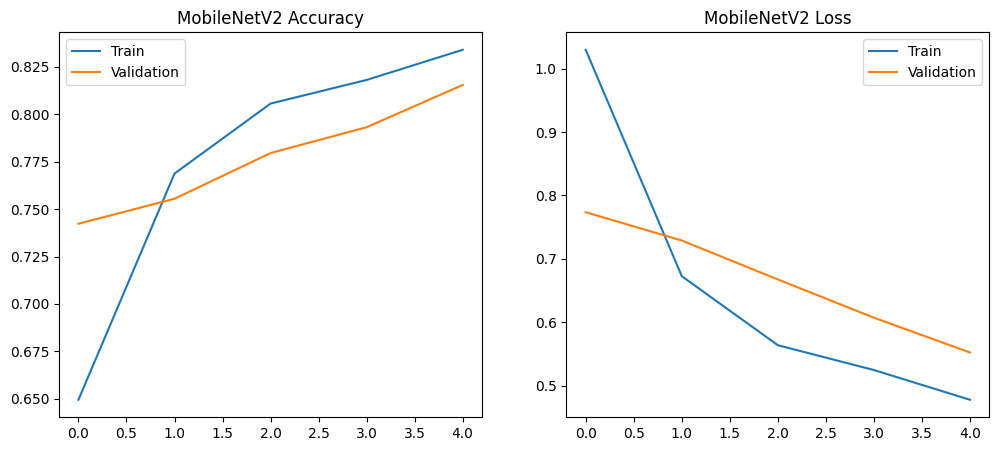

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])
plt.title('MobileNetV2 Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history_mobilenet.history['loss'])
plt.plot(history_mobilenet.history['val_loss'])
plt.title('MobileNetV2 Loss')
plt.legend(['Train','Validation'])

plt.show()

In [14]:
val_data.reset()

predictions_mobile = model_mobilenet.predict(val_data)

y_pred_mobile = np.argmax(predictions_mobile, axis=1)
y_true_mobile = val_data.classes

class_names = list(val_data.class_indices.keys())

print(classification_report(
    y_true_mobile,
    y_pred_mobile,
    target_names=class_names
))

35/35 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step
                                      precision    recall  f1-score   support

                      Bacterial_spot       0.84      0.81      0.83       200
                        Early_blight       0.76      0.73      0.75       200
                         Late_blight       0.67      0.81      0.73       200
                           Leaf_Mold       0.74      0.81      0.77       200
                  Septoria_leaf_spot       0.81      0.60      0.69       200
Spider_mites Two-spotted_spider_mite       0.89      0.79      0.84       200
                         Target_Spot       0.73      0.80      0.76       200
       Tomato_Yellow_Leaf_Curl_Virus       1.00      0.91      0.95       200
                 Tomato_mosaic_virus       0.90      0.93      0.91       200
                             healthy       0.80      0.93      0.86       200
                      powdery_mildew       0.90      0.85      0.87       200

                       

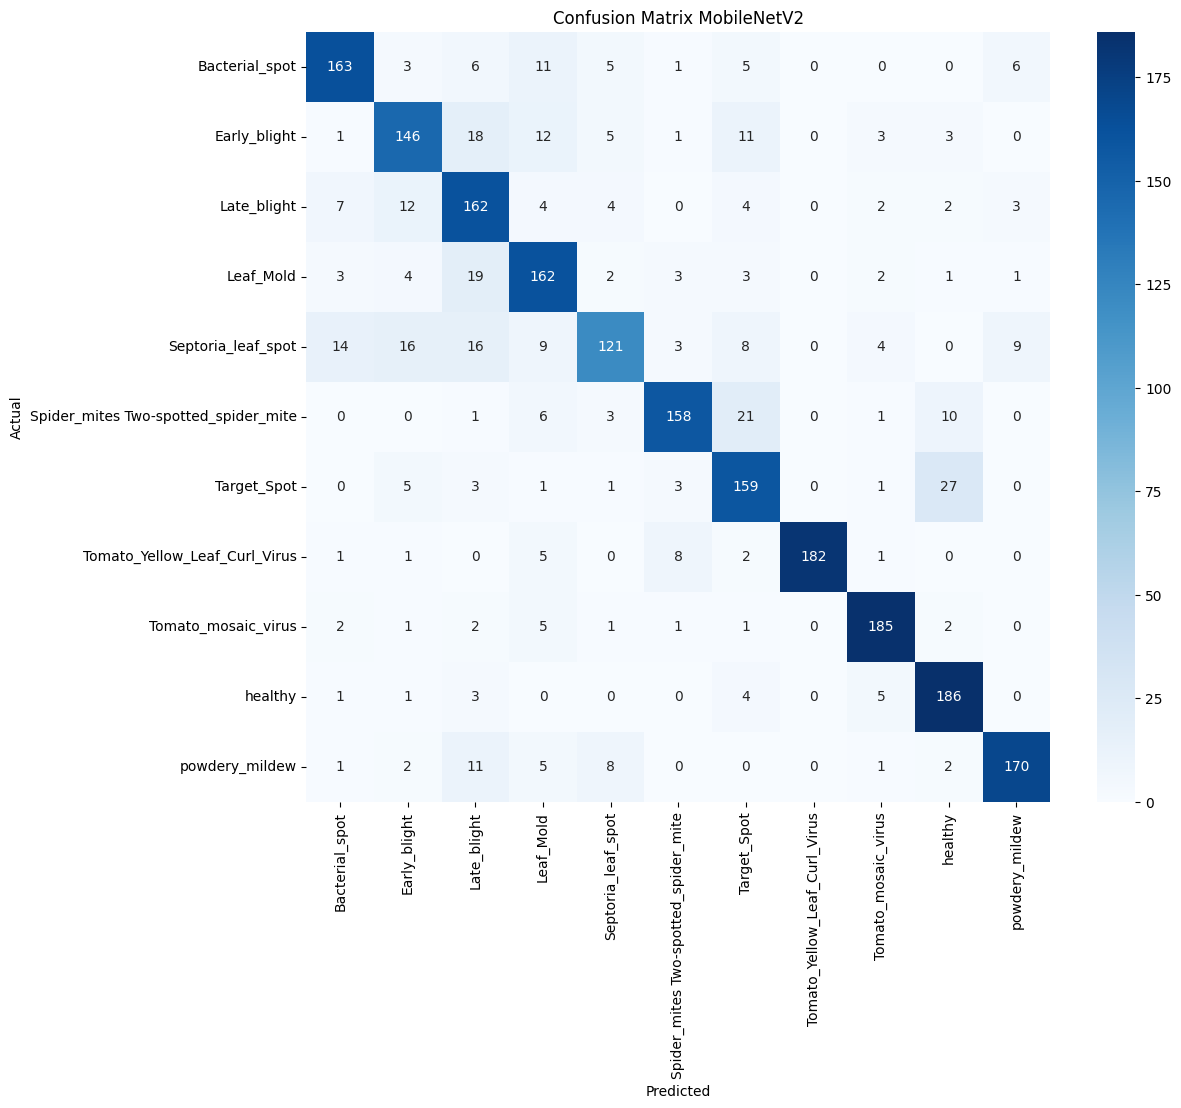

In [15]:
cm_mobile = confusion_matrix(
    y_true_mobile,
    y_pred_mobile
)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm_mobile,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix MobileNetV2')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## 6. ResNet50

In [16]:
train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [17]:
train_data_resnet = train_datagen_resnet.flow_from_directory(
    TRAIN_PATH,
    target_size=(224,224),
    batch_size=64,
    class_mode='categorical'
)

val_data_resnet = val_datagen_resnet.flow_from_directory(
    VAL_PATH,
    target_size=(224,224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

Found 11000 images belonging to 11 classes.
Found 2200 images belonging to 11 classes.


In [18]:
base_resnet = ResNet50(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_resnet.trainable = False

In [19]:
model_resnet = Sequential([
    base_resnet,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(train_data_resnet.num_classes, activation='softmax')
])

In [20]:
from tensorflow.keras.optimizers import Adam

model_resnet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,146,571 (92.11 MB)

 Trainable params: 558,859 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 7. Training ResNet50

In [21]:
history_resnet = model_resnet.fit(
    train_data_resnet,
    validation_data=val_data_resnet,
    epochs=5
)

Epoch 1/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 513s 3s/step - accuracy: 0.5708 - loss: 1.3797 - val_accuracy: 0.7050 - val_loss: 0.9257
Epoch 2/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 494s 3s/step - accuracy: 0.7848 - loss: 0.7093 - val_accuracy: 0.8032 - val_loss: 0.6508
Epoch 3/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 464s 3s/step - accuracy: 0.8330 - loss: 0.5452 - val_accuracy: 0.8064 - val_loss: 0.5835
Epoch 4/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 492s 3s/step - accuracy: 0.8601 - loss: 0.4541 - val_accuracy: 0.8223 - val_loss: 0.5244
Epoch 5/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 472s 3s/step - accuracy: 0.8736 - loss: 0.4006 - val_accuracy: 0.8468 - val_loss: 0.4629


## 8. Evaluasi ResNet50

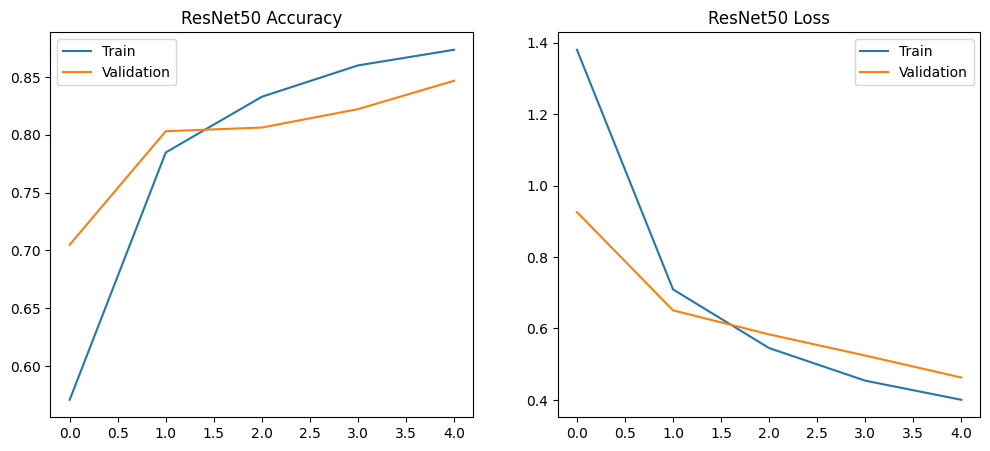

In [22]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_resnet.history['accuracy'])
plt.plot(history_resnet.history['val_accuracy'])
plt.title('ResNet50 Accuracy')
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history_resnet.history['loss'])
plt.plot(history_resnet.history['val_loss'])
plt.title('ResNet50 Loss')
plt.legend(['Train','Validation'])

plt.show()

In [23]:
val_data_resnet.reset()

predictions_resnet = model_resnet.predict(
    val_data_resnet
)

y_pred_resnet = np.argmax(
    predictions_resnet,
    axis=1
)

y_true_resnet = val_data_resnet.classes

print(classification_report(
    y_true_resnet,
    y_pred_resnet,
    target_names=class_names
))

35/35 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step
                                      precision    recall  f1-score   support

                      Bacterial_spot       0.85      0.85      0.85       200
                        Early_blight       0.88      0.71      0.78       200
                         Late_blight       0.68      0.85      0.76       200
                           Leaf_Mold       0.88      0.80      0.84       200
                  Septoria_leaf_spot       0.79      0.72      0.76       200
Spider_mites Two-spotted_spider_mite       0.77      0.96      0.85       200
                         Target_Spot       0.87      0.79      0.83       200
       Tomato_Yellow_Leaf_Curl_Virus       0.99      0.86      0.93       200
                 Tomato_mosaic_virus       0.90      0.95      0.93       200
                             healthy       0.87      0.94      0.90       200
                      powdery_mildew       0.92      0.86      0.89       200

                       

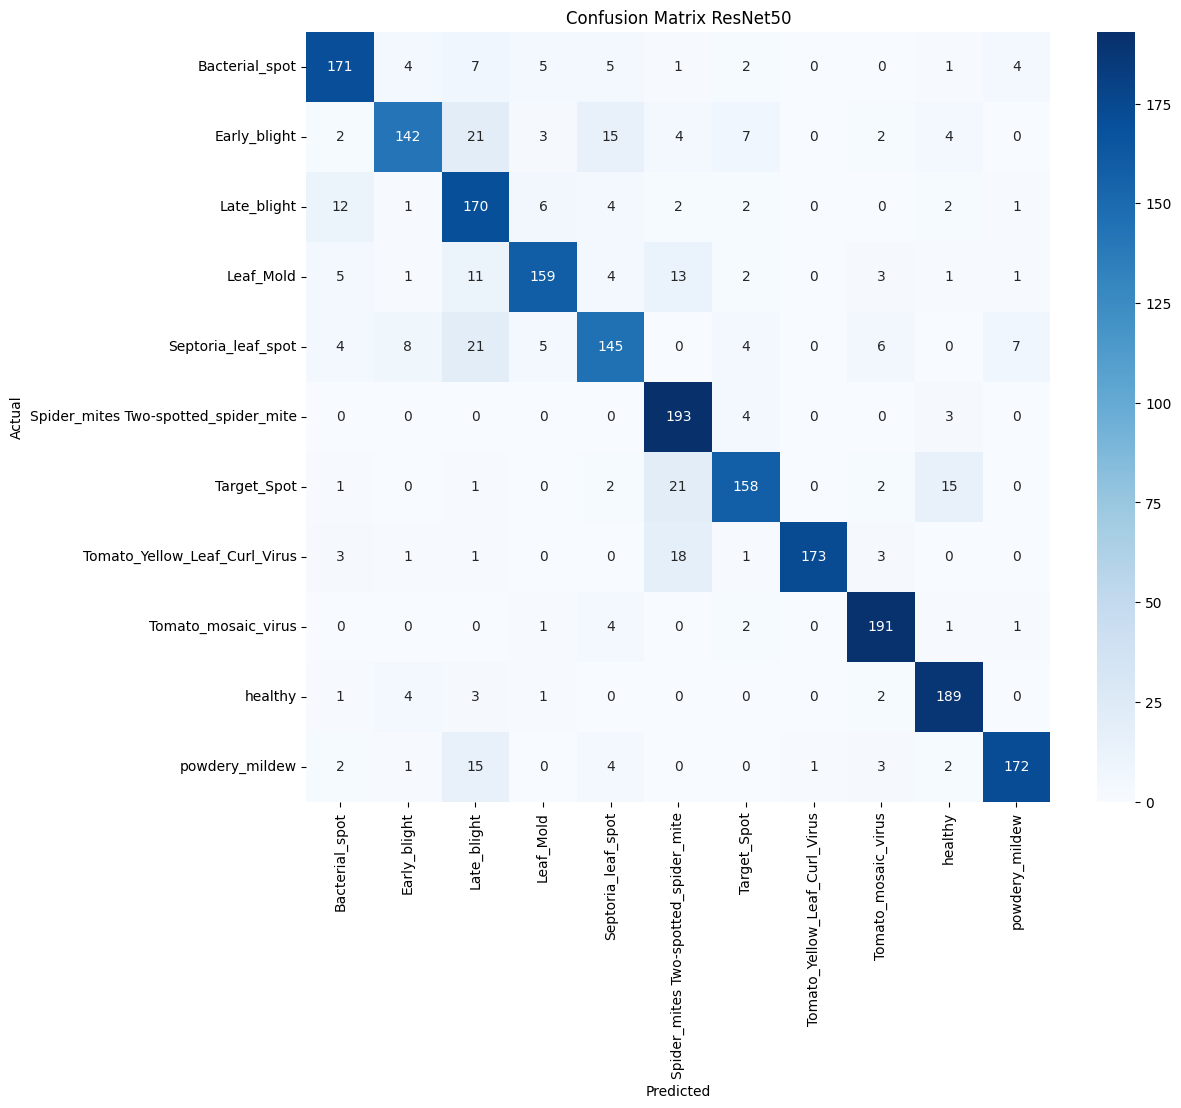

In [24]:
cm_resnet = confusion_matrix(
    y_true_resnet,
    y_pred_resnet
)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm_resnet,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Confusion Matrix ResNet50')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## 9. Perbandingan Model

In [29]:
comparison = pd.DataFrame({
    'Parameter':[
        'Train Accuracy',
        'Validation Accuracy',
        'Train Loss',
        'Validation Loss',
        'Kecepatan Training',
        'Jumlah Parameter',
        'Ukuran Model'
    ],

    'MobileNetV2':[
        '83.76%',
        '80.64%',
        '0.4678',
        '0.5832',
        'Lebih Cepat',
        'Lebih Sedikit',
        'Lebih Ringan'
    ],

    'ResNet50':[
        '91.91%',
        '88.27%',
        '0.2634',
        '0.3521',
        'Lebih Lambat',
        'Lebih Banyak',
        'Lebih Besar'
    ]
})

comparison

,Parameter,MobileNetV2,ResNet50
0,Train Accuracy,83.76%,91.91%
1,Validation Accuracy,80.64%,88.27%
2,Train Loss,0.4678,0.2634
3,Validation Loss,0.5832,0.3521
4,Kecepatan Training,Lebih Cepat,Lebih Lambat
5,Jumlah Parameter,Lebih Sedikit,Lebih Banyak
6,Ukuran Model,Lebih Ringan,Lebih Besar


## 10. Pengujian Gambar Baru

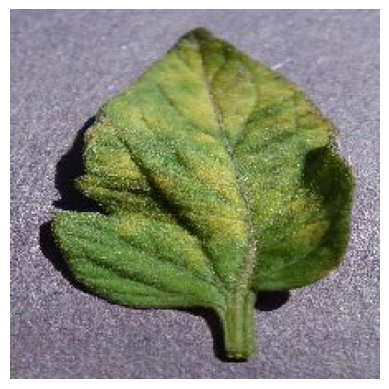


HASIL PREDIKSI



,Model,Prediksi,Confidence (%)
0,MobileNetV2,Late_blight,50.200001
1,ResNet50,Leaf_Mold,86.889999


In [36]:
from tensorflow.keras.preprocessing import image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

img_path = r"D:\ML\Tugas Akhir\Dataset_UAS\test\test15.jpg"

img = image.load_img(img_path, target_size=(224,224))

plt.imshow(img)
plt.axis("off")
plt.show()

# MobileNet
img_mobile = image.img_to_array(img)
img_mobile = np.expand_dims(img_mobile, axis=0)
img_mobile = img_mobile / 255.0

pred_mobile = model_mobilenet.predict(img_mobile, verbose=0)

kelas_mobile = class_names[np.argmax(pred_mobile)]
conf_mobile = np.max(pred_mobile) * 100

# ResNet
img_resnet = image.img_to_array(img)
img_resnet = np.expand_dims(img_resnet, axis=0)
img_resnet = preprocess_input(img_resnet)

pred_resnet = model_resnet.predict(img_resnet, verbose=0)

kelas_resnet = class_names[np.argmax(pred_resnet)]
conf_resnet = np.max(pred_resnet) * 100

hasil = pd.DataFrame({
    "Model": ["MobileNetV2", "ResNet50"],
    "Prediksi": [kelas_mobile, kelas_resnet],
    "Confidence (%)": [round(conf_mobile,2), round(conf_resnet,2)]
})

print("\nHASIL PREDIKSI\n")
display(hasil)

## 11. Kesimpulan
Berdasarkan hasil pengujian yang telah dilakukan, model MobileNetV2 dan ResNet50 mampu melakukan klasifikasi penyakit daun tomat dengan baik. ResNet50 memberikan performa terbaik dengan akurasi validasi yang lebih tinggi dibandingkan MobileNetV2 sehingga dipilih sebagai model terbaik pada penelitian ini.